# Real DES data: look, cut, save

Turns the downloaded DES Y6 Gold strips into the small table the rest of this
project reads. Every cell is meant to be run and looked at, not trusted.

**What is already done**, by `scripts/fetch_des_dr2.py` — see `manifest.json`
beside the data, which records the exact SQL:

- stars are `0 <= EXT_XGB <= 1`, the selection streamobs's DES Y6 model
  reproduces, so the real catalogue and the injected streams are one sample
- `flags_footprint = 1`, `flags_foreground = 0`, `flags_gold = 0`
- extinction applied (the `_corrected` PSF magnitudes)
- magnitudes 15.5 to 25, errors better than 0.54 mag (signal-to-noise above 2)

**What is left to this notebook**: the signal-to-noise cut, the 16 to 24.5
clip the trained models assume, and writing the four columns the pipeline
reads.

| column | meaning |
|---|---|
| `ra`, `dec` | degrees |
| `des_yr6_g_obs`, `des_yr6_r_obs` | magnitudes, extinction applied, cut and clipped |

The namespace `des_yr6` comes from `SURVEY`/`RELEASE` in the stream-parameters
experiment (`streamobs.columns.obs_col`); change those and this name changes.

## 1. Load the strips

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("~/Documents/data/DES_yr6").expanduser()

manifest = json.loads((DATA / "manifest.json").read_text())
print(manifest["description"])
print(f"\n{manifest['totals']['rows']:,} stars in "
      f"{manifest['totals']['files']} strips "
      f"({manifest['totals']['bytes'] / 1e9:.2f} GB)")
print("\nselection already applied:")
for key, value in manifest["selection"].items():
    if key != "sql_where":
        print(f"  {key}: {value}")

DES DR2 point sources for the streamgoggles stream search. One parquet file per one-degree declination strip; concatenate them for the full footprint.

49,068,865 stars in 75 strips (1.70 GB)

selection already applied:
  star_galaxy: ext_xgb BETWEEN 0 AND 1 -- 0 <= EXT_XGB <= 1 is the selection streamobs's DES Y6 model reproduces, so the real catalogue and the injected streams are the same sample. ext_coadd and ext_mash are stored for diagnostics but do not define the sample; the union of those two misses 14.6% of EXT_XGB stars.
  quality: flags_footprint = 1, flags_foreground = 0, flags_gold = 0. flags_foreground is the reason to prefer Gold: it removes bright-star haloes and nearby galaxies, which are what fake a localized overdensity.
  signal_to_noise: > 2 in both g and r (a floor, not the analysis cut: choose that downstream, the errors are kept)
  magnitudes: 15.5 to 25.0 dereddened in both bands, wider than the pipeline's 16 to 24.5 clip on purpose
  extinction: already applied

In [11]:
# Only the columns needed here; ext_coadd and ext_mash stay on disk as
# diagnostics. DEC_RANGE = None reads the whole footprint: about 49 million
# stars, roughly 1.6 GB in memory, so close other notebooks first.
COLUMNS = ["ra", "dec", "g", "r", "g_err", "r_err"]
DEC_RANGE = None                # or e.g. (-60, -40) for one band of sky

strips = sorted(DATA.glob("des_y6gold_dec*.parquet"))
if DEC_RANGE is not None:
    low, high = DEC_RANGE
    strips = [s for s in strips if low <= float(s.stem.split("dec")[1]) < high]

# Strips outside the footprint hold zero rows. Reading them is harmless but
# concatenating them is not, if their columns were ever written with parquet
# type "null": that promotes ra and dec to object and every later cast fails.
frames = [pd.read_parquet(s, columns=COLUMNS) for s in strips]
frames = [f for f in frames if len(f)]
raw = pd.concat(frames, ignore_index=True).astype(
    {"ra": "float64", "dec": "float64"}
)
print(f"{len(raw):,} stars from {len(frames)} non-empty strips "
      f"({raw.memory_usage(deep=True).sum() / 1e9:.2f} GB)")
raw.describe().T[["count", "mean", "min", "max"]]

49,068,865 stars from 75 strips


,count,mean,min,max
g,49068865.0,22.548441,15.500396,25.000000
r,49068865.0,21.625275,15.500000,25.000000
g_err,49068865.0,0.054204,0.000112,0.542816
r_err,49068865.0,0.030563,0.000103,0.542427


In [13]:
print(raw.columns)

Index(['ra', 'dec', 'g', 'r', 'g_err', 'r_err'], dtype='str')


## 2. Where it is on the sky

Look for holes, the survey edge, and density gradients. The foreground mask is
already applied, so the small empty discs are removed bright stars — those are
supposed to be there.

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'

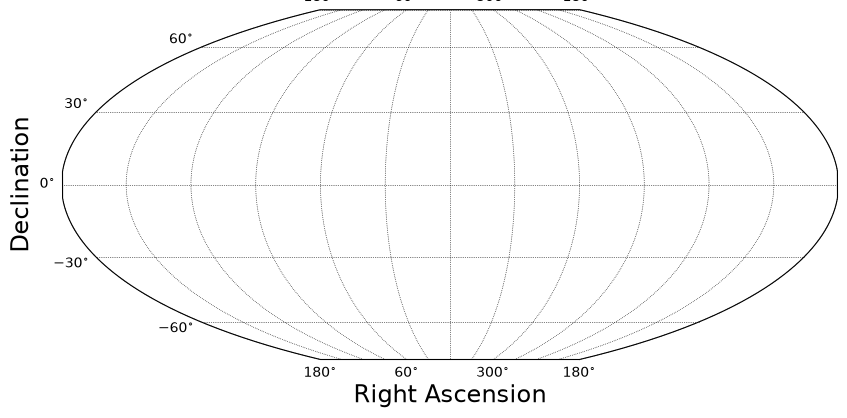

In [12]:
import matplotlib.pyplot as plt
import skyproj

fig, ax = plt.subplots(figsize=(10, 5))
sp = skyproj.McBrydeSkyproj(ax=ax)
sp.draw_hpxbin(raw["ra"].to_numpy(), raw["dec"].to_numpy(), nside=256)
sp.draw_colorbar(label="stars per pixel")
ax.set_title("EXT_XGB stars, before the magnitude and signal-to-noise cuts")
plt.show()

## 3. Colour-magnitude space

The stellar locus should be tight — these are already classified as point
sources. Where the counts turn over is the real depth.

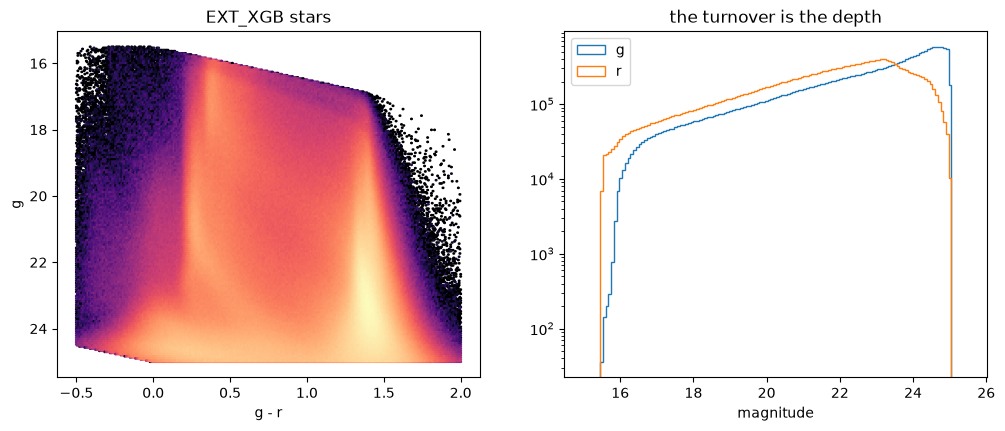

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hexbin(raw["g"] - raw["r"], raw["g"], gridsize=250,
               extent=(-0.5, 2.0, 15.5, 25), bins="log", cmap="magma")
axes[0].invert_yaxis()
axes[0].set_xlabel("g - r"); axes[0].set_ylabel("g")
axes[0].set_title("EXT_XGB stars")
for band in ("g", "r"):
    axes[1].hist(raw[band], bins=140, range=(15, 25.5), histtype="step", label=band)
axes[1].set_yscale("log"); axes[1].set_xlabel("magnitude"); axes[1].legend()
axes[1].set_title("the turnover is the depth")
plt.show()

## 4. Where the signal-to-noise cut bites

`sigma_m = 1.0857 / SNR`. Read off the magnitude where the threshold line
crosses the bulk of the stars: **that, not the 24.5 clip, is your real depth**.
streamobs's DES Y6 model is anchored at a signal-to-noise of 5 with median
depth g = 25.025, r = 24.850, so a cut well brighter than that is leaving
usable stars behind — and whatever is chosen here has to be applied to the
simulated catalogue too, or the two samples stop being comparable.

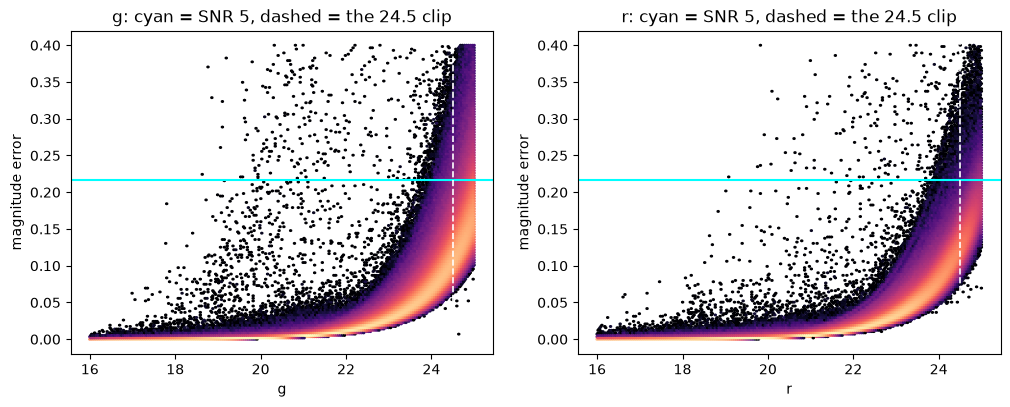

In [6]:
SNR_MIN = 5.0
MAX_MAGERR = 1.0857 / SNR_MIN

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, band in zip(axes, ["g", "r"]):
    ax.hexbin(raw[band], raw[f"{band}_err"], gridsize=200,
              extent=(16, 25, 0, 0.4), bins="log", cmap="magma")
    ax.axhline(MAX_MAGERR, color="cyan", lw=1.5)
    ax.axvline(24.5, color="white", ls="--", lw=1.2)
    ax.set_xlabel(band); ax.set_ylabel("magnitude error")
    ax.set_title(f"{band}: cyan = SNR {SNR_MIN:g}, dashed = the 24.5 clip")
plt.show()

## 5. Cut

In [7]:
CLIP = {"g": (16.0, 24.5), "r": (16.0, 24.5)}

masks = {
    f"SNR > {SNR_MIN:g}": (raw["g_err"] < MAX_MAGERR) & (raw["r_err"] < MAX_MAGERR),
    "magnitude clip": (
        raw["g"].between(*CLIP["g"]) & raw["r"].between(*CLIP["r"])
    ),
}
for name, mask in masks.items():
    print(f"  {name:<16} keeps {100 * mask.mean():5.1f}% on its own")

keep = np.logical_and.reduce(list(masks.values()))
print(f"\ntogether: {keep.sum():,} of {len(raw):,} ({100 * keep.mean():.1f}%)")

cut = pd.DataFrame({
    "ra": raw.loc[keep, "ra"].to_numpy(),
    "dec": raw.loc[keep, "dec"].to_numpy(),
    "des_yr6_g_obs": raw.loc[keep, "g"].to_numpy(),
    "des_yr6_r_obs": raw.loc[keep, "r"].to_numpy(),
})
cut.head()

  SNR > 5          keeps  99.4% on its own
  magnitude clip   keeps  82.1% on its own

together: 18,475,608 of 22,512,547 (82.1%)


,ra,dec,des_yr6_g_obs,des_yr6_r_obs
0,349.345621,-41.000000,17.460819,17.073694
1,317.238655,-41.000000,22.901951,22.683823
2,39.211607,-40.999999,22.201300,21.807539
3,325.495163,-40.999996,24.042877,22.663649
4,307.448462,-40.999995,23.581800,22.259516


## 6. The same two plots again

The locus should be unchanged in shape and simply truncated at the faint end.
If the density map grew new structure, the cut is interacting with the depth
variation across the footprint — which matters, because a detector reads that
structure as signal.

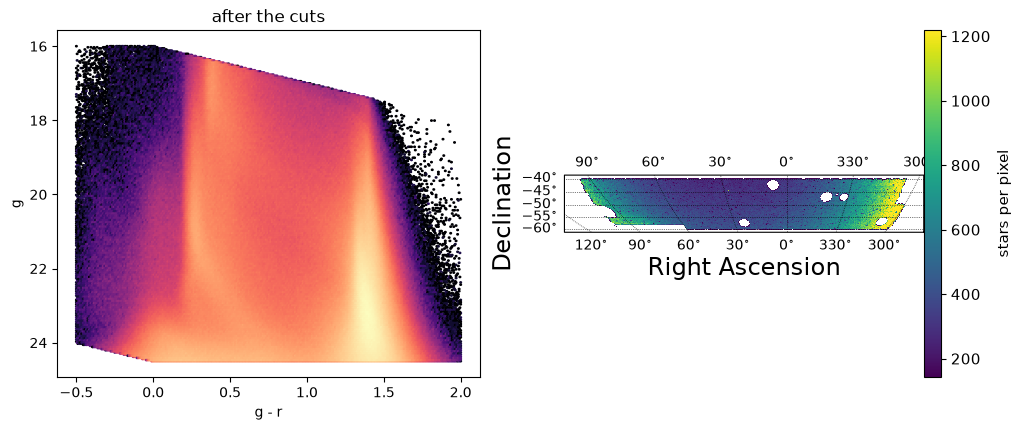

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hexbin(cut["des_yr6_g_obs"] - cut["des_yr6_r_obs"], cut["des_yr6_g_obs"],
               gridsize=250, extent=(-0.5, 2.0, 16, 24.5), bins="log", cmap="magma")
axes[0].invert_yaxis(); axes[0].set_xlabel("g - r"); axes[0].set_ylabel("g")
axes[0].set_title("after the cuts")
sp = skyproj.McBrydeSkyproj(ax=axes[1])
sp.draw_hpxbin(cut["ra"].to_numpy(), cut["dec"].to_numpy(), nside=256)
sp.draw_colorbar(label="stars per pixel")
axes[1].set_title("density after the cuts")
plt.show()

## 7. Save the pipeline input

Four columns, which is all the injection and background code reads.

In [9]:
OUT = DATA / "des_yr6_pipeline_input.parquet"
cut.to_parquet(OUT, index=False)
(DATA / "des_yr6_pipeline_input.json").write_text(json.dumps({
    "description": "Input table for the streamgoggles injection pipeline.",
    "built_from": manifest["source"],
    "inherited_selection": manifest["selection"],
    "applied_here": {
        "signal_to_noise": f"> {SNR_MIN:g} in both bands",
        "magnitude_clip": {k: list(v) for k, v in CLIP.items()},
        "dec_range": DEC_RANGE,
    },
    "columns": ["ra", "dec", "des_yr6_g_obs", "des_yr6_r_obs"],
    "rows": int(len(cut)),
}, indent=2) + "\n")
print(f"{len(cut):,} stars -> {OUT} ({OUT.stat().st_size / 1e6:.0f} MB)")

18,475,608 stars -> /Users/pelissier/Documents/data/DES_yr6/des_yr6_pipeline_input.parquet (420 MB)


## 8. Does the pipeline accept it?

The real test of the contract: build one matched-filter map from this table
with the experiment's own filter. If this runs and the map has counts in it,
the file is usable as a background everywhere else.

In [10]:
import importlib.util as u

spec = u.spec_from_file_location("sp_run", "../scripts/experiments/stream_parameters/run.py")
run = u.module_from_spec(spec); spec.loader.exec_module(run)

from streamgoggles.background import build_raw_background_maps
from streamgoggles.matched_filter import PixelizationSpec, build_matched_filters

pix = PixelizationSpec(nside=512, image_size_pix=(96, 96))
filters = build_matched_filters(run.FILTERS, namespace=f"{run.SURVEY}_{run.RELEASE}")
maps = build_raw_background_maps(
    catalog=pd.read_parquet(OUT),
    matched_filters=filters,
    bands=["g", "r"],
    distance_moduli=[17.0],
    pix=pix,
)
raw_map, valid = maps["good"][17.0]
print(f"selected stars: {raw_map.sum():,.0f}")
print(f"covered pixels: {valid.sum():,} "
      f"(mean {raw_map[valid].mean():.2f} stars per pixel)")

selected stars: 1,006,388
covered pixels: 144,754 (mean 6.95 stars per pixel)
